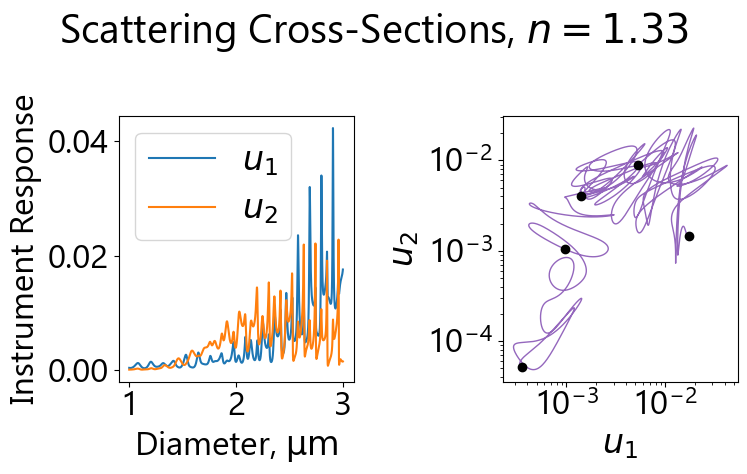

In [ ]:
import shutil
import os
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from numba import njit
import afnlib

# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : 22}

# matplotlib.rc('font', **font)

# plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams.update({"font.size": 24})
plt.rcParams["font.family"] = "gadugi"

# Parameters
d_lim = [1, 3]
refr_vals = [1.4]
d_res = 4096
n_res = 4096

marker_d = [1, 1.5, 2, 2.5, 3.0]
marker_diam, marker_refr = np.meshgrid(marker_d, refr_vals)

# Generate data
diam, refr = np.meshgrid(np.linspace(d_lim[0], d_lim[1], d_res), refr_vals)

Cp, Cs = afnlib.cross_section(diam, refr)
Cp_marker, Cs_marker = afnlib.cross_section(marker_d, marker_refr)

fig, ax = plt.subplots(1, 2, figsize=[8, 5])


ax[0].plot(diam.ravel(), Cp.ravel(), label="$u_1$")
ax[0].plot(diam.ravel(), Cs.ravel(), label="$u_2$")
ax[0].set(xlabel="Diameter, $\\mathrm{\\mu m}$",ylabel="Instrument Response")
ax[0].legend()

for i, refr_val in enumerate(refr_vals):
    ax[1].plot(Cp[i, :], Cs[i, :], label=refr_val, linewidth=1, color="C4")

for i, refr_val in enumerate(refr_vals):
    ax[1].plot(Cp_marker[i, :], Cs_marker[i, :], color="k", marker="o", linewidth=0)

ax[1].set(
    xlabel="$u_1$",
    ylabel="$u_2$",
    xscale="log",
    yscale="log",
)
fig.suptitle("Scattering Cross-Sections, $n=1.33$",)
fig.tight_layout()

fig.savefig("non-uniqueness-line.pdf", transparent=True)

In [ ]:
Cp

array([[0.00036034, 0.00035813, 0.00035602, ..., 0.01736479, 0.01745887,
        0.0175611 ]], shape=(1, 4096))